In [1]:
import cv2
import matplotlib.pyplot as plt

In [33]:
img1 = cv2.imread("raw-captures/front.jpg")
img2 = cv2.imread("raw-captures/side.jpg")

img1_rgb = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2_rgb = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

In [34]:
gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

In [37]:
orb = cv2.ORB_create(nfeatures=500)

In [39]:
kp1, des1 = orb.detectAndCompute(gray1, None)
kp2, des2 = orb.detectAndCompute(gray2, None)

print("Keypoints in Image 1:", len(kp1))
print("Keypoints in Image 2:", len(kp2))

Keypoints in Image 1: 500
Keypoints in Image 2: 500


In [41]:
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)

matches = bf.match(des1, des2)

In [43]:
matches = sorted(matches, key=lambda x: x.distance)

In [69]:
good_matches = [m for m in matches if m.distance < 35]

In [71]:
matched_img = cv2.drawMatches(
    img1,
    kp1,
    img2,
    kp2,
    good_matches,
    None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

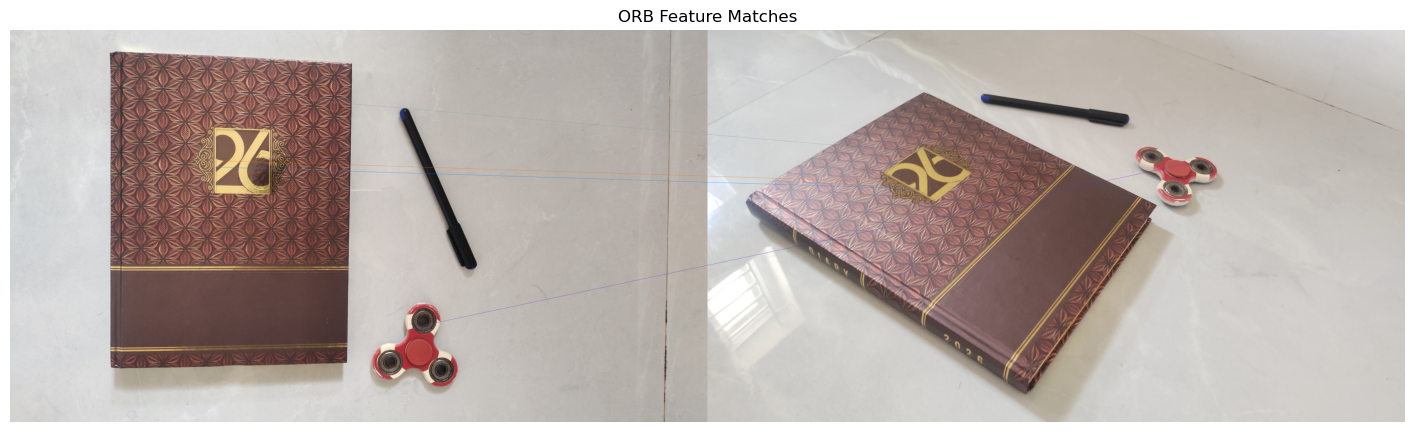

In [73]:
plt.figure(figsize=(18,8))
plt.imshow(cv2.cvtColor(matched_img, cv2.COLOR_BGR2RGB))
plt.title("ORB Feature Matches")
plt.axis("off")
plt.show()

In [74]:
print("Total Keypoints in Image 1:", len(kp1))
print("Total Keypoints in Image 2:", len(kp2))
print("Total Matches:", len(matches))
print("Good Matches Displayed:", len(good_matches))

Total Keypoints in Image 1: 500
Total Keypoints in Image 2: 500
Total Matches: 122
Good Matches Displayed: 4
